# Pure GRU — S&P 500 (Gaussian Noise Evaluation)

Time series forecasting with Gaussian noise robustness analysis.
- Noise levels: [0.0, 0.005, 0.05, 0.1]
- 60 runs × 100 epochs per noise level
- Last 60 for test, rest for training, NO validation

In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.10.0+cu128
NumPy version: 2.0.2


In [2]:
# ============================================================
# Pure GRU — Gated Recurrent Unit (Stateful)
# ============================================================
# Cho et al. (2014) GRU.
# Maintained hidden state across sequence steps to match LSTM-SNP.

import torch
import torch.nn as nn

class PureGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=8, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.u = None  # Internal state matching LSTM-SNP interface

    def reset_states(self, batch_size, device):
        self.u = torch.zeros(1, batch_size, self.hidden_dim, device=device)

    def detach_states(self):
        if self.u is not None:
            self.u = self.u.detach()

    def forward(self, x):
        if self.u is None or self.u.device != x.device:
            self.reset_states(x.size(0), x.device)
            
        gru_out, self.u = self.gru(x, self.u)
        out = self.fc(gru_out[:, -1, :])
        return out

def build_model(input_dim=1, units=8):
    return PureGRU(input_dim=input_dim, hidden_dim=units, output_dim=1)

# Quick architecture check
model = build_model(input_dim=1, units=8)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")


PureGRU(
  (gru): GRU(1, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)
Total params: 273


In [3]:
# Quick model check
model = build_model(input_dim=1, units=8)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

PureGRU(
  (gru): GRU(1, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)
Total params: 273


## Data Pipeline — S&P 500

In [4]:
import os
for f in os.listdir('/kaggle/input/datasets/satabartosarkar123/sp500-csv'):
    print(f)

sp500.csv


In [5]:
# ============================================================
# 1. Load Time Series Data
# ============================================================
series = pd.read_csv(
    '/kaggle/input/datasets/satabartosarkar123/sp500-csv/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

original_raw_values = series.values.flatten()
print(f"Base data shape: {original_raw_values.shape}")
print(f"First 5 values: {original_raw_values[:5]}")

Base data shape: (251,)
First 5 values: [2038.199951 2013.780029 2011.709961 1985.319946 1945.969971]


In [6]:
# ============================================================
# 2. First-Order Differencing
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

In [7]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

## Training Loop

In [8]:
# ============================================================
# Gaussian Noise Evaluation + 60-Run Experiment Protocol (PyTorch)
# ============================================================
import torch
import torch.nn as nn

s_x = np.std(original_raw_values)
noise_levels = [0.0, 0.005, 0.05, 0.1]
_molab_results = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- [PyTorch] RUNNING ON {device} ---\n")

for lam in noise_levels:
    sigma = lam * s_x
    print("\n" + "="*80)
    print(f"EVALUATING NOISE LEVEL: {lam*100:.1f}% (lambda={lam}, sigma={sigma:.6f})")
    print("="*80 + "\n")
    
    np.random.seed(42)
    torch.manual_seed(42)
    noise = np.random.normal(0, sigma, size=original_raw_values.shape)
    raw_values = original_raw_values + noise
    
    # 2. Difference
    diff_values = difference(raw_values, 1)
    # 3. Supervised (lag=1)
    supervised = timeseries_to_supervised(diff_values, 1)
    # 4. Split (Last 60 for test, NO validation)
    train, test = supervised[:-60], supervised[-60:]
    # 5. Scale
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    train_scaled = scaler.transform(train)
    test_scaled = scaler.transform(test)
    # 6. Reshape
    X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    
    all_rmse = []
    all_mse = []
    all_nmse = []
    all_predictions = []
    all_losses = []
    
    for run in range(60):
        print(f'\n===== RUN {run+1}/60 [Noise {lam*100:.1f}%] =====')
        
        np.random.seed(run)
        torch.manual_seed(run)
        
        model = build_model(input_dim=1, units=8).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        
        # Pre-tensorize training data
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
        n_samples = X_train_t.size(0)
        
        run_losses = []
        for epoch in range(100):
            model.train()
            model.reset_states(1, device)
            
            epoch_loss = 0.0
            for i in range(n_samples):
                x_i = X_train_t[i:i+1]
                y_i = y_train_t[i:i+1]
                
                optimizer.zero_grad()
                pred = model(x_i)
                loss = criterion(pred.squeeze(-1), y_i)
                loss.backward()
                optimizer.step()
                model.detach_states()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / n_samples
            run_losses.append(avg_loss)
            if (epoch+1) % 10 == 0:
                print(f"  Epoch {epoch+1}/100, Loss: {avg_loss:.6f}")
        
        all_losses.append(run_losses)
        print(f'Training complete for run {run+1}')
        
        # Warm-up: condition hidden states on training data
        model.eval()
        with torch.no_grad():
            model.reset_states(1, device)
            for i in range(len(train_scaled)):
                X_raw = train_scaled[i, 0:-1]
                X_input = torch.tensor(X_raw, dtype=torch.float32).view(1, 1, len(X_raw)).to(device)
                model(X_input)
        
        # Test predictions (single-step)
        predictions = []
        model.eval()
        with torch.no_grad():
            for i in range(len(test_scaled)):
                X = test_scaled[i, 0:-1]
                X_input = torch.tensor(X, dtype=torch.float32).view(1, 1, len(X)).to(device)
                yhat = model(X_input).item()
                
                # Invert scaling
                new_row = list(X) + [yhat]
                array = np.array(new_row).reshape(1, len(new_row))
                inverted = scaler.inverse_transform(array)[0, -1]
                
                # Invert differencing
                inverted = inverted + raw_values[len(train) + i]
                predictions.append(inverted)
        
        # Compute metrics
        actual = raw_values[-len(predictions):]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mse = mean_squared_error(actual, predictions)
        meanV = np.mean(actual)
        dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
        nmse = mse / np.power(dominator, 2)
        
        all_rmse.append(rmse)
        all_mse.append(mse)
        all_nmse.append(nmse)
        all_predictions.append(predictions)
        
        print(f'Run {run+1} \u2014 RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')
    
    # End of 60 runs for this noise level
    best_idx = np.argmin(all_rmse)
    
    print(f'\n===== STATS FOR NOISE {lam*100:.1f}% (60 runs) =====')
    print(f'RMSE: {np.mean(all_rmse):.6f} +/- {np.std(all_rmse):.6f}')
    print(f'MSE:  {np.mean(all_mse):.6f} +/- {np.std(all_mse):.6f}')
    print(f'NMSE: {np.mean(all_nmse):.10f} +/- {np.std(all_nmse):.10f}')
    print(f'Best run: {best_idx+1} (RMSE: {all_rmse[best_idx]:.6f})')
    
    _molab_results.append([lam, 
        np.mean(all_rmse), np.std(all_rmse),
        np.mean(all_mse), np.std(all_mse),
        np.mean(all_nmse), np.std(all_nmse),
        all_rmse[best_idx], all_predictions[best_idx], all_losses[best_idx], raw_values.copy()])



--- [PyTorch] RUNNING ON cuda ---


EVALUATING NOISE LEVEL: 0.0% (lambda=0.0, sigma=0.000000)

X_train shape: (190, 1, 1), y_train shape: (190,)

===== RUN 1/60 [Noise 0.0%] =====
  Epoch 10/100, Loss: 0.056045
  Epoch 20/100, Loss: 0.055551
  Epoch 30/100, Loss: 0.055067
  Epoch 40/100, Loss: 0.054705
  Epoch 50/100, Loss: 0.054578
  Epoch 60/100, Loss: 0.054565
  Epoch 70/100, Loss: 0.054550
  Epoch 80/100, Loss: 0.054470
  Epoch 90/100, Loss: 0.054347
  Epoch 100/100, Loss: 0.054234
Training complete for run 1
Run 1 — RMSE: 11.363436, MSE: 129.127680, NMSE: 0.0007940103

===== RUN 2/60 [Noise 0.0%] =====
  Epoch 10/100, Loss: 0.057434
  Epoch 20/100, Loss: 0.056906
  Epoch 30/100, Loss: 0.056344
  Epoch 40/100, Loss: 0.055847
  Epoch 50/100, Loss: 0.055634
  Epoch 60/100, Loss: 0.055635
  Epoch 70/100, Loss: 0.055690
  Epoch 80/100, Loss: 0.055759
  Epoch 90/100, Loss: 0.055880
  Epoch 100/100, Loss: 0.055949
Training complete for run 2
Run 2 — RMSE: 11.214036, MSE: 125.754612, NMS

## Results


RESULTS FOR NOISE LEVEL: 0.0%
Mean RMSE: 11.333636 +/- 0.099366
Mean MSE:  128.461172 +/- 2.252827
Mean NMSE: 0.0007930472 +/- 0.0000226905
Best RMSE: 11.145157


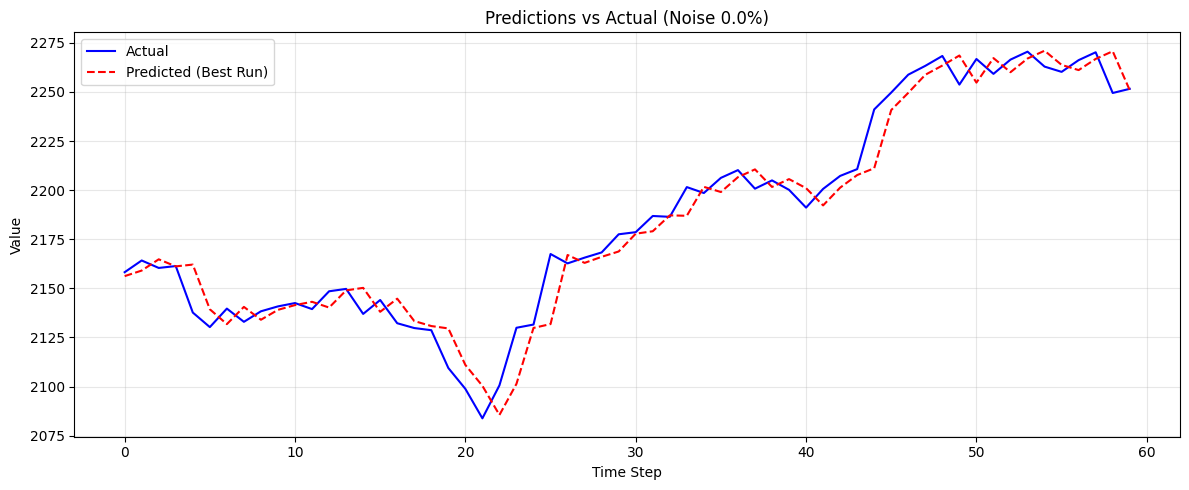

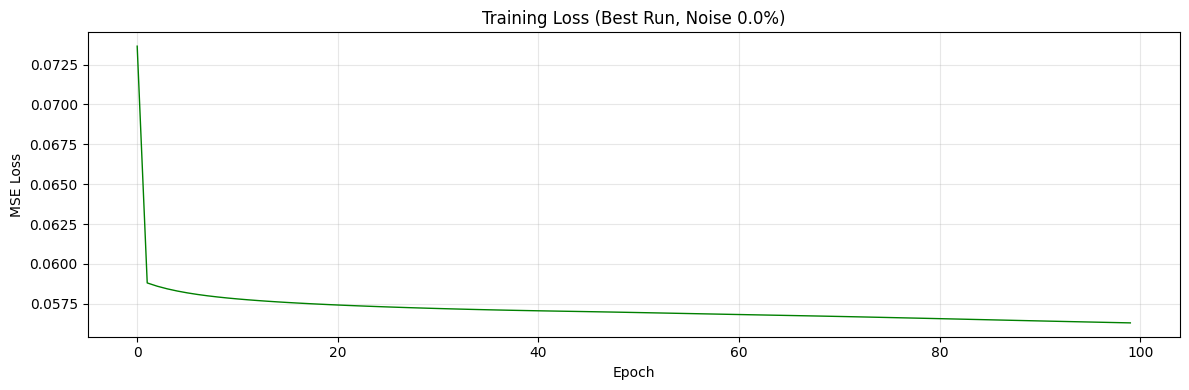


RESULTS FOR NOISE LEVEL: 0.5%
Mean RMSE: 11.375827 +/- 0.101673
Mean MSE:  129.419780 +/- 2.316421
Mean NMSE: 0.0008027035 +/- 0.0000235332
Best RMSE: 11.177978


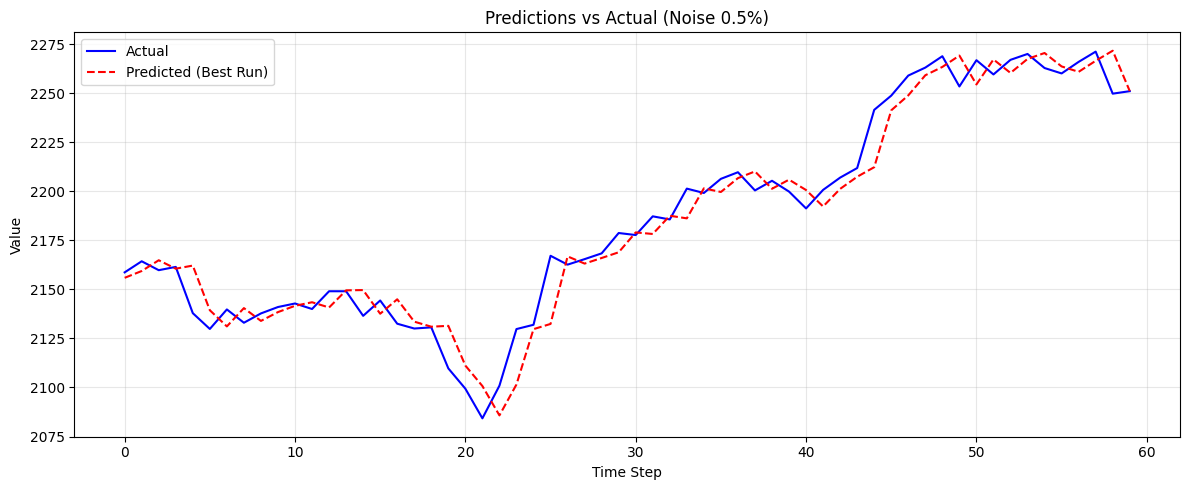

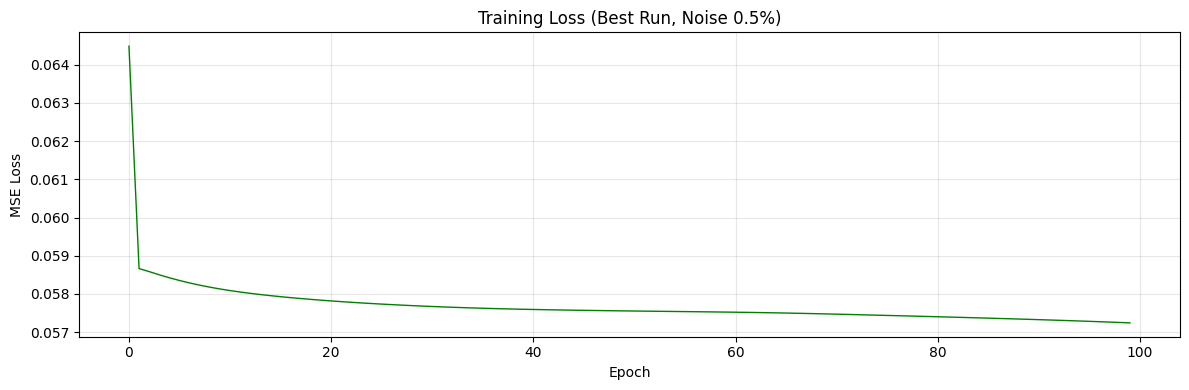


RESULTS FOR NOISE LEVEL: 5.0%
Mean RMSE: 13.552724 +/- 0.063480
Mean MSE:  183.680367 +/- 1.720195
Mean NMSE: 0.0011655663 +/- 0.0000216551
Best RMSE: 13.410189


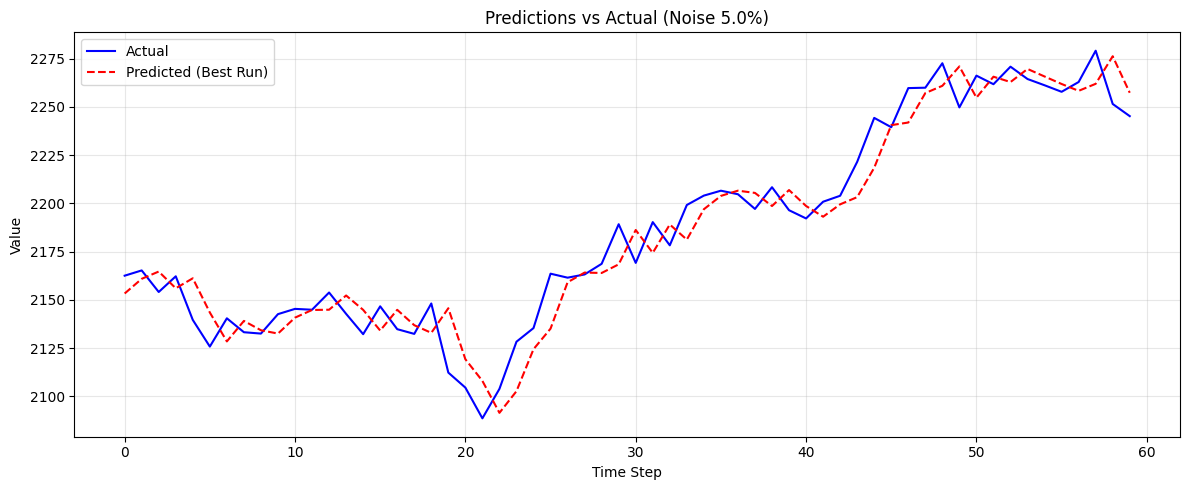

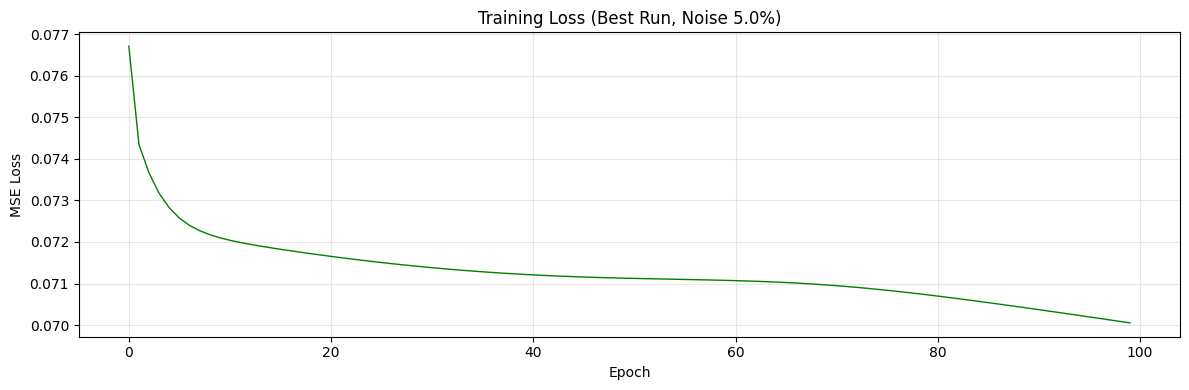


RESULTS FOR NOISE LEVEL: 10.0%
Mean RMSE: 17.889219 +/- 0.076935
Mean MSE:  320.030064 +/- 2.753222
Mean NMSE: 0.0021010301 +/- 0.0000294108
Best RMSE: 17.646280


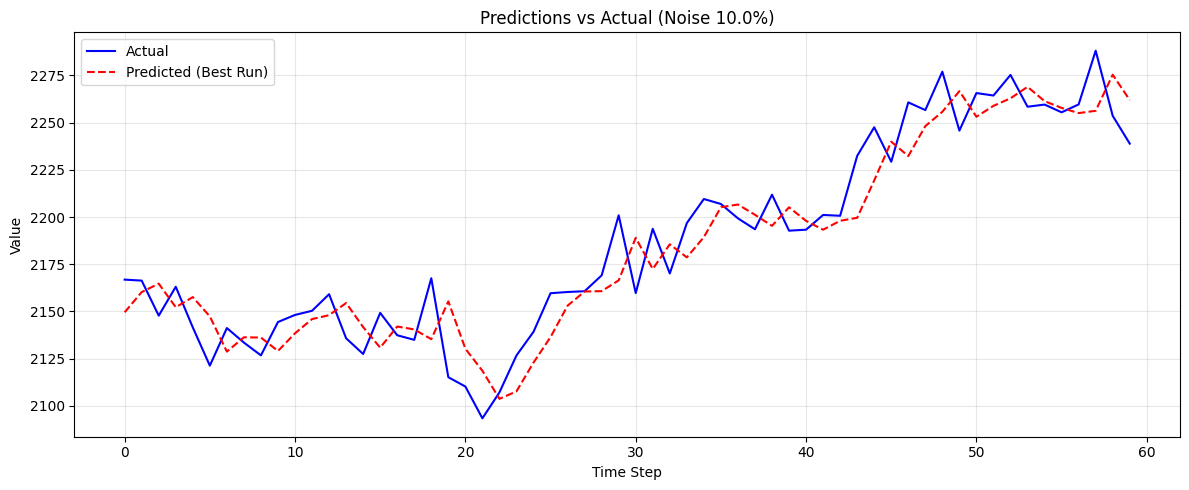

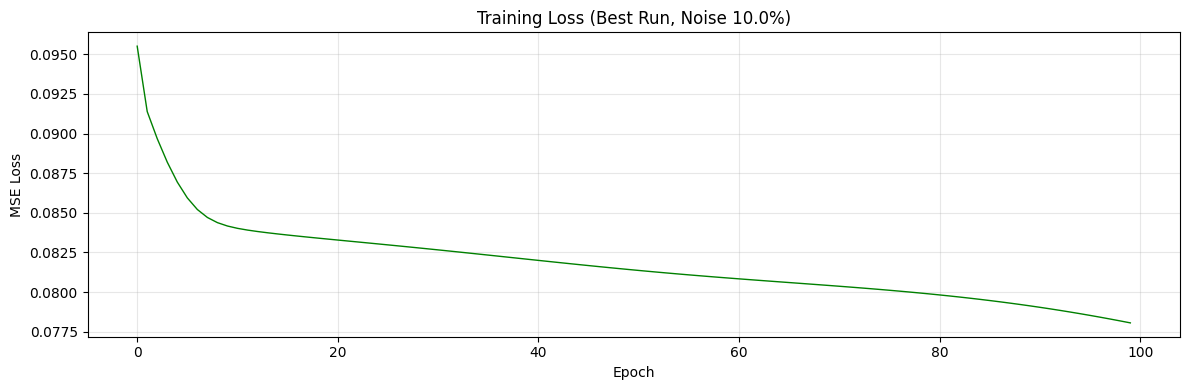


FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
|   Noise Level | RMSE (mean+/-std)      | MSE (mean+/-std)        | NMSE (mean+/-std)             |   Best RMSE |
|---------------|------------------------|-------------------------|-------------------------------|-------------|
|         0     | 11.333636 +/- 0.099366 | 128.461172 +/- 2.252827 | 0.0007930472 +/- 0.0000226905 |     11.1452 |
|         0.005 | 11.375827 +/- 0.101673 | 129.419780 +/- 2.316421 | 0.0008027035 +/- 0.0000235332 |     11.178  |
|         0.05  | 13.552724 +/- 0.063480 | 183.680367 +/- 1.720195 | 0.0011655663 +/- 0.0000216551 |     13.4102 |
|         0.1   | 17.889219 +/- 0.076935 | 320.030064 +/- 2.753222 | 0.0021010301 +/- 0.0000294108 |     17.6463 |


In [9]:
# ============================================================
# Final Metrics Summary & Plots per Noise Level
# ============================================================
from tabulate import tabulate

for entry in _molab_results:
    lam = entry[0]
    mean_rmse, std_rmse = entry[1], entry[2]
    mean_mse, std_mse = entry[3], entry[4]
    mean_nmse, std_nmse = entry[5], entry[6]
    best_rmse_val = entry[7]
    best_predictions = entry[8]
    best_losses = entry[9]
    raw_values_for_plot = entry[10]
    
    print("\n" + "="*80)
    print(f"RESULTS FOR NOISE LEVEL: {lam*100:.1f}%")
    print("="*80)
    
    print(f'Mean RMSE: {mean_rmse:.6f} +/- {std_rmse:.6f}')
    print(f'Mean MSE:  {mean_mse:.6f} +/- {std_mse:.6f}')
    print(f'Mean NMSE: {mean_nmse:.10f} +/- {std_nmse:.10f}')
    print(f'Best RMSE: {best_rmse_val:.6f}')
    
    actual = raw_values_for_plot[-60:]
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
             linewidth=1.5, linestyle='--')
    plt.title(f'Predictions vs Actual (Noise {lam*100:.1f}%)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(best_losses, color='green', linewidth=1.0)
    plt.title(f'Training Loss (Best Run, Noise {lam*100:.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS")
print("="*80)
df_res = pd.DataFrame(
    [[r[0], f'{r[1]:.6f} +/- {r[2]:.6f}', f'{r[3]:.6f} +/- {r[4]:.6f}', 
      f'{r[5]:.10f} +/- {r[6]:.10f}', f'{r[7]:.6f}'] for r in _molab_results],
    columns=['Noise Level', 'RMSE (mean+/-std)', 'MSE (mean+/-std)', 'NMSE (mean+/-std)', 'Best RMSE']
)
print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))
